## Effective Visualization


In [9]:
import pandas as pd
from matplotlib import pyplot as plt

In [5]:
data=pd.read_csv("/Users/haijingtu/Library/CloudStorage/OneDrive-IndianaStateUniversity/TEACHING/ECT637-DataVis/week1/vehicles.csv")

/var/folders/6w/q_2rdhnn4gv696y7yxdd7vrr0000gp/T/ipykernel_77254/1927781036.py:1: DtypeWarning: Columns (68,70,71,72,73,74,76,79) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("/Users/haijingtu/Library/CloudStorage/OneDrive-IndianaStateUniversity/TEACHING/ECT637-DataVis/week1/vehicles.csv")


In [6]:
data=data[['year','make','model','displ','city08','highway08','comb08','cylinders']]

In [7]:
print(data)

       year        make                model  displ  city08  highway08  \
0      1985  Alfa Romeo   Spider Veloce 2000    2.0      19         25   
1      1985     Ferrari           Testarossa    4.9       9         14   
2      1985       Dodge              Charger    2.2      23         33   
3      1985       Dodge  B150/B250 Wagon 2WD    5.2      10         12   
4      1993      Subaru     Legacy AWD Turbo    2.2      17         23   
...     ...         ...                  ...    ...     ...        ...   
41139  1993      Subaru               Legacy    2.2      19         26   
41140  1993      Subaru               Legacy    2.2      20         28   
41141  1993      Subaru           Legacy AWD    2.2      18         24   
41142  1993      Subaru           Legacy AWD    2.2      18         24   
41143  1993      Subaru     Legacy AWD Turbo    2.2      16         21   

       comb08  cylinders  
0          21        4.0  
1          11       12.0  
2          27        4.0  
3  

### Scatterplot

Text(0.5, 1.0, 'Implicit Figure and Axes')

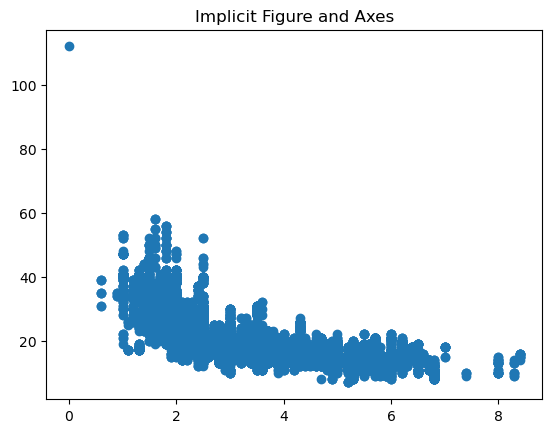

In [14]:
#implicit, plot without explicitly defining figures and axes
plt.scatter(data['displ'],data['comb08'])
plt.title("Implicit Figure and Axes")


Text(0, 0.5, 'Combined MPG')

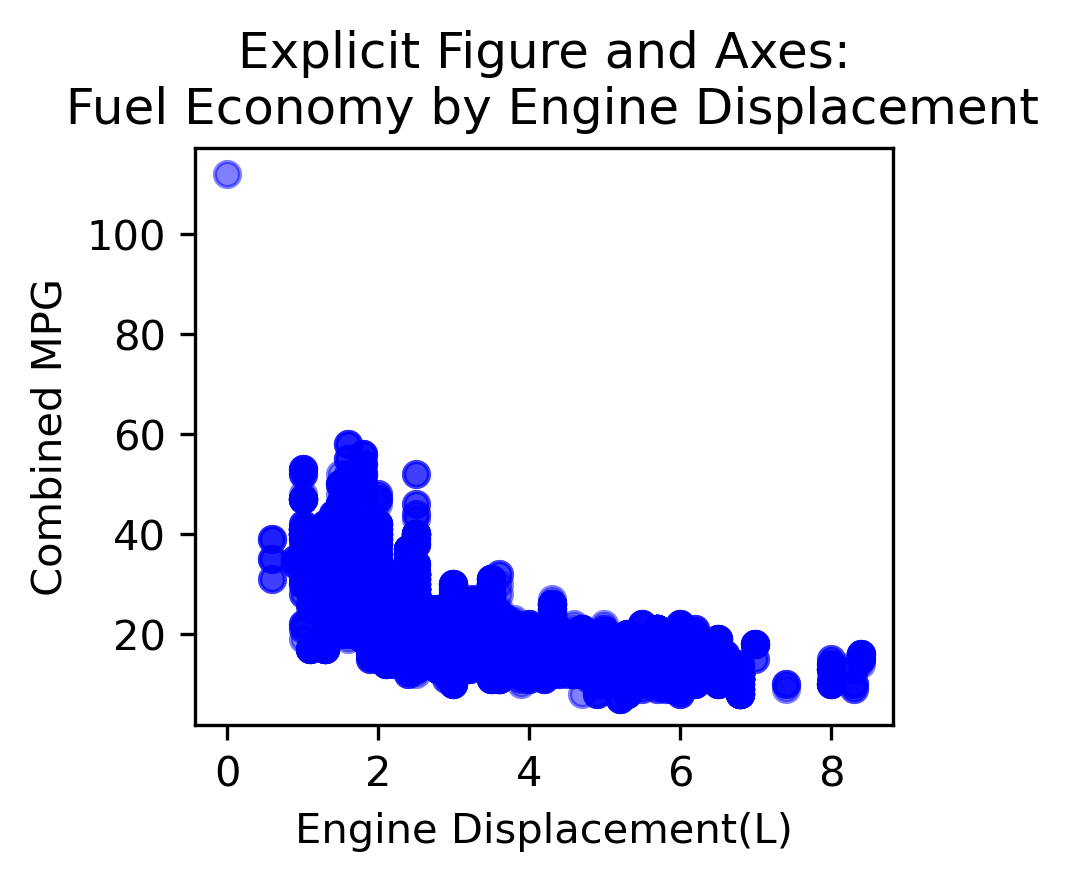

In [19]:
#Explicit figure and axes
fig,ax=plt.subplots(figsize=(3,2.5),dpi=300)
ax.scatter(data['displ'],data['comb08'],color='blue',alpha=0.5)
ax.set_title('Explicit Figure and Axes:\n Fuel Economy by Engine Displacement')
ax.set_xlabel("Engine Displacement(L)")
ax.set_ylabel('Combined MPG')

In [ ]:
#save the figure
#fig.savefig('path/path/directory',dpi=300)

In [25]:
data['make'].value_counts()

make
Chevrolet                      4003
Ford                           3371
Dodge                          2583
GMC                            2494
Toyota                         2071
                               ... 
Volga Associated Automobile       1
Panos                             1
Mahindra                          1
Excalibur Autos                   1
London Coach Co Inc               1
Name: count, Length: 136, dtype: int64

Text(0.5, 0.98, 'Fuel Economy Metrics by Engine Displacement')

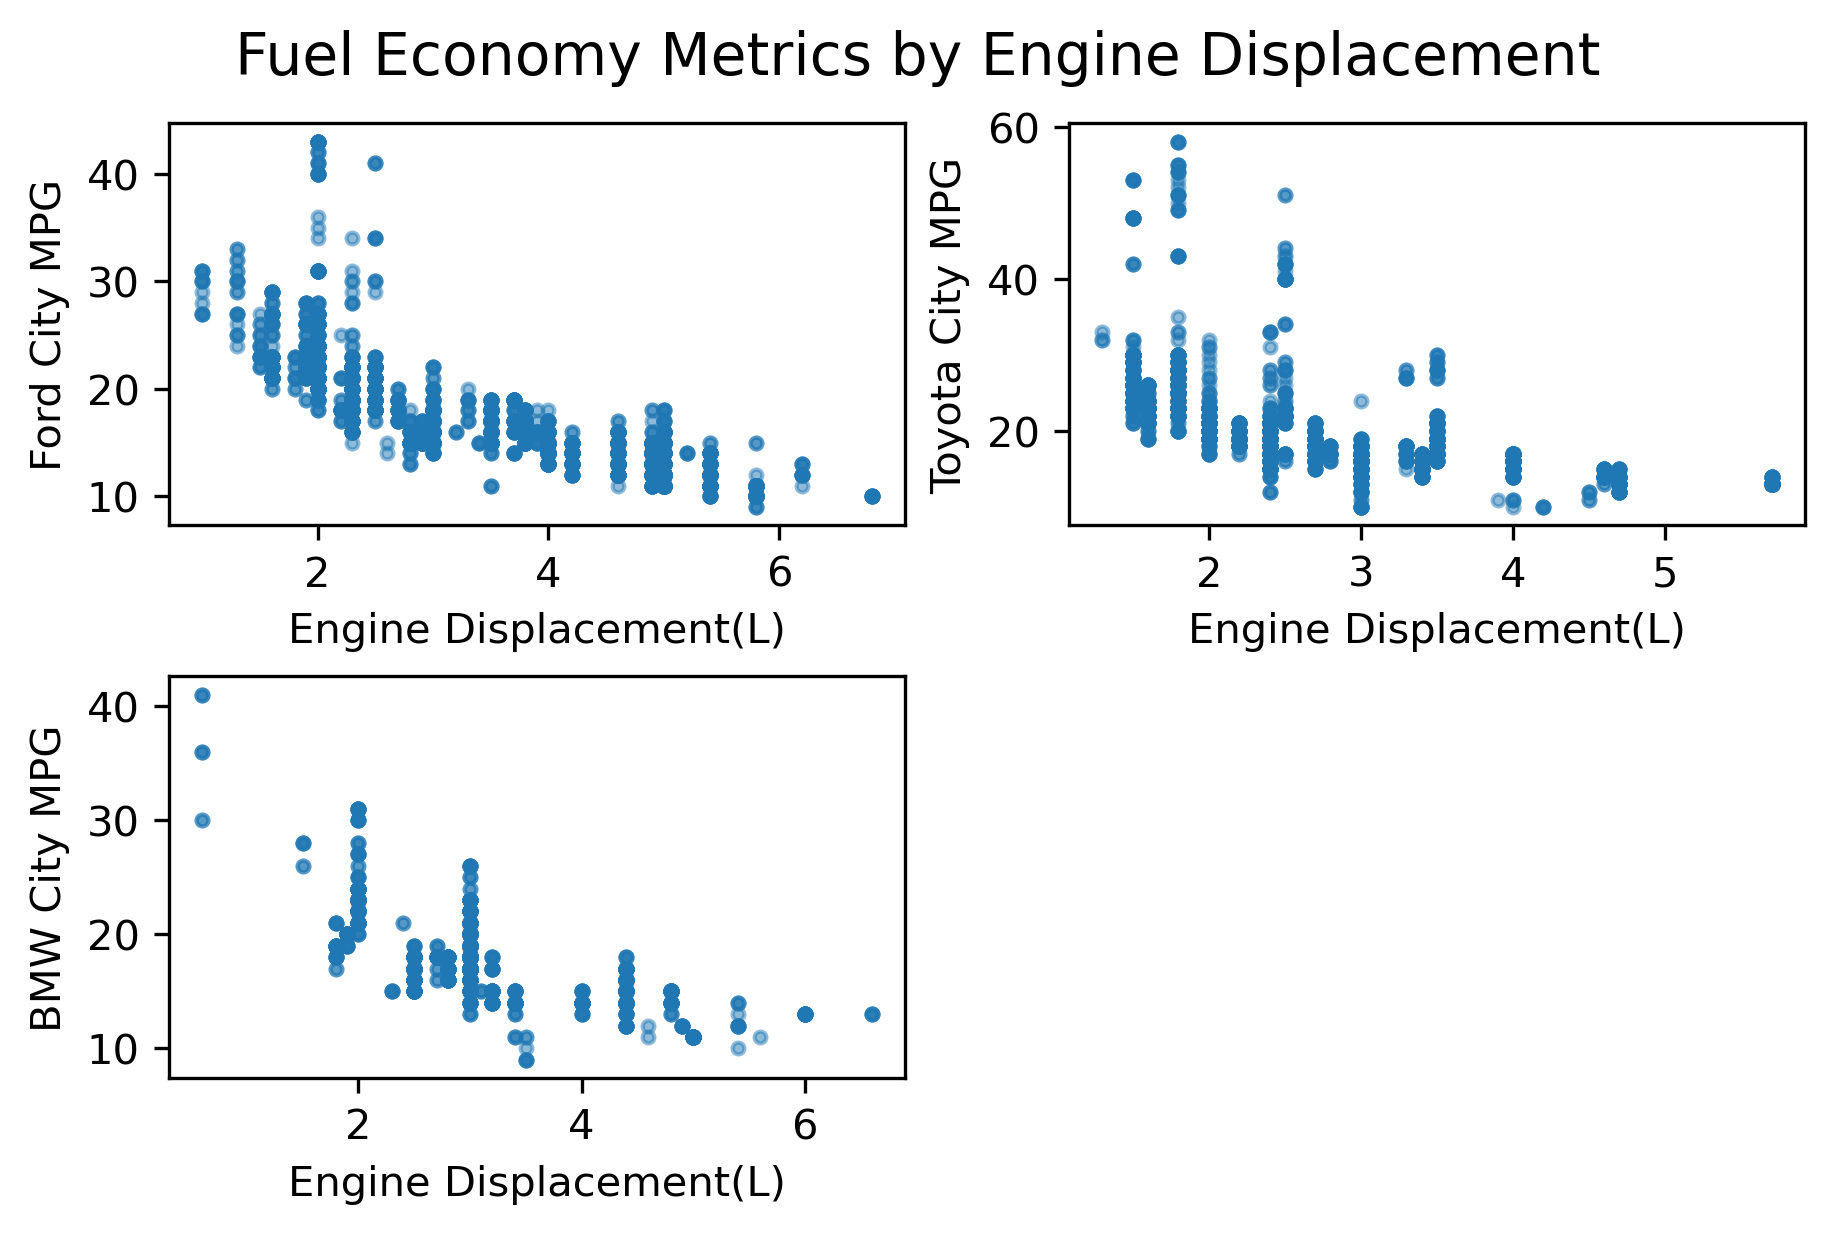

In [36]:
#Multiple Axes
fig,axes=plt.subplots(2,2,figsize=(6,4),dpi=300,constrained_layout=True)
flax_axes=axes.flatten() #from numpy to transform multidimension to one-dimension
for ax, make in zip(flax_axes,['Ford','Toyota','BMW']):
    make_data=data.query(f'make=="{make}"')
    #This uses the .query() method from pandas to filter the data DataFrame where the make column is equal to "Toyota".
    ax.scatter(make_data['displ'],make_data['city08'],alpha=0.5,s=8)
    ax.set_xlabel('Engine Displacement(L)')
    ax.set_ylabel(f'{make} City MPG')
    #f-strings (f'...') allow embedding expressions inside string literals using curly braces {}.
    # The expression inside {} is evaluated and inserted into the string

#hide empty subplot
axes[1,1].axis('off')
#add a figure wide title
fig.suptitle('Fuel Economy Metrics by Engine Displacement', fontsize=14)

Text(0.5, 0.98, 'Fuel Economy Metrics by Engine Displacement')

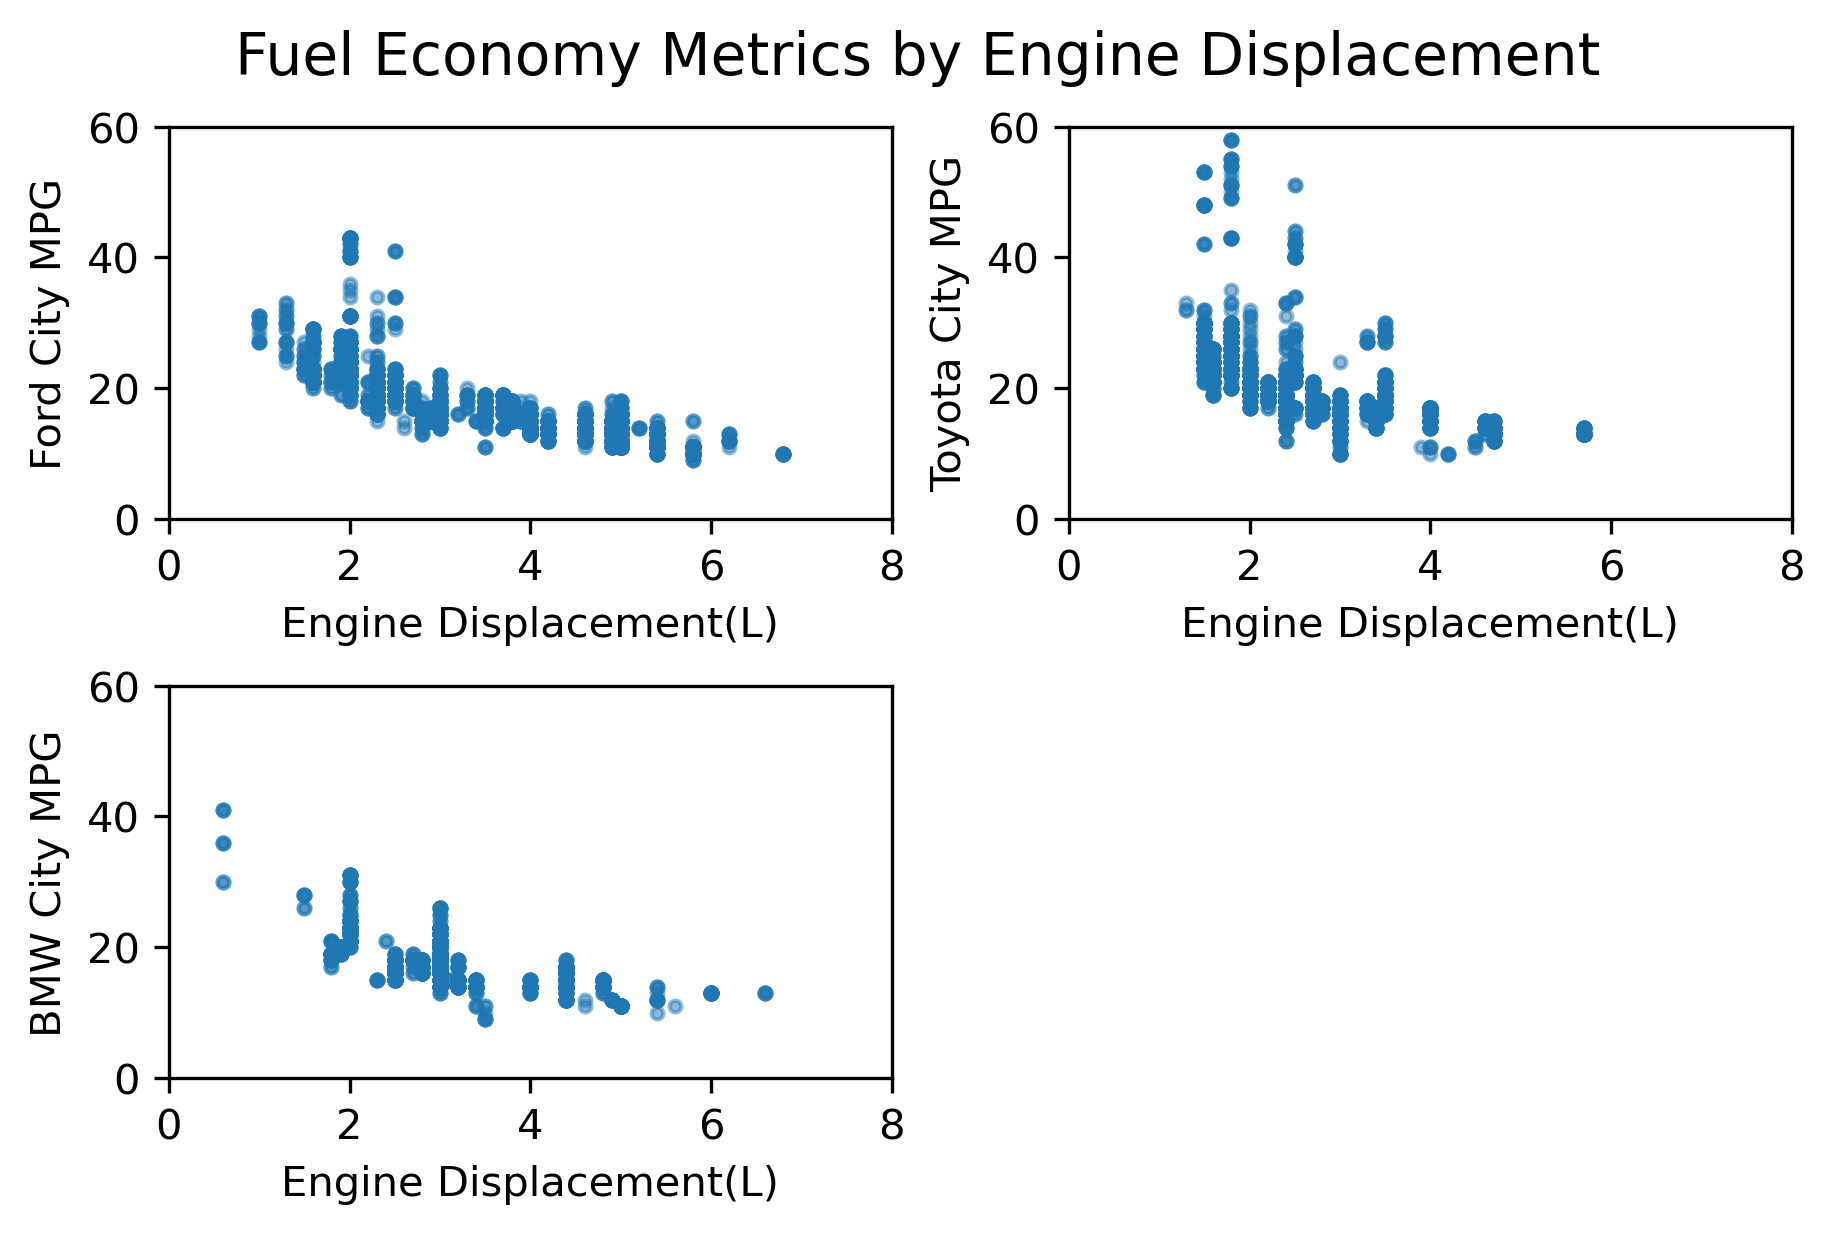

In [39]:
#Create consistent axis limits across subplots
#Multiple Axes
fig,axes=plt.subplots(2,2,figsize=(6,4),dpi=300,constrained_layout=True)
flax_axes=axes.flatten() #from numpy to transform multidimension to one-dimension
#limits for axis in all plots: 
x_limits=(0,8)
y_limits=(0,60)
for ax, make in zip(flax_axes,['Ford','Toyota','BMW']):
    make_data=data.query(f'make=="{make}"')
    #This uses the .query() method from pandas to filter the data DataFrame where the make column is equal to "Toyota".
    ax.scatter(make_data['displ'],make_data['city08'],alpha=0.5,s=8)
    ax.set_xlabel('Engine Displacement(L)')
    ax.set_ylabel(f'{make} City MPG')
    #f-strings (f'...') allow embedding expressions inside string literals using curly braces {}.
    # The expression inside {} is evaluated and inserted into the string
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)

#hide empty subplot
axes[1,1].axis('off')
#add a figure wide title
fig.suptitle('Fuel Economy Metrics by Engine Displacement', fontsize=14)

### Line Plots

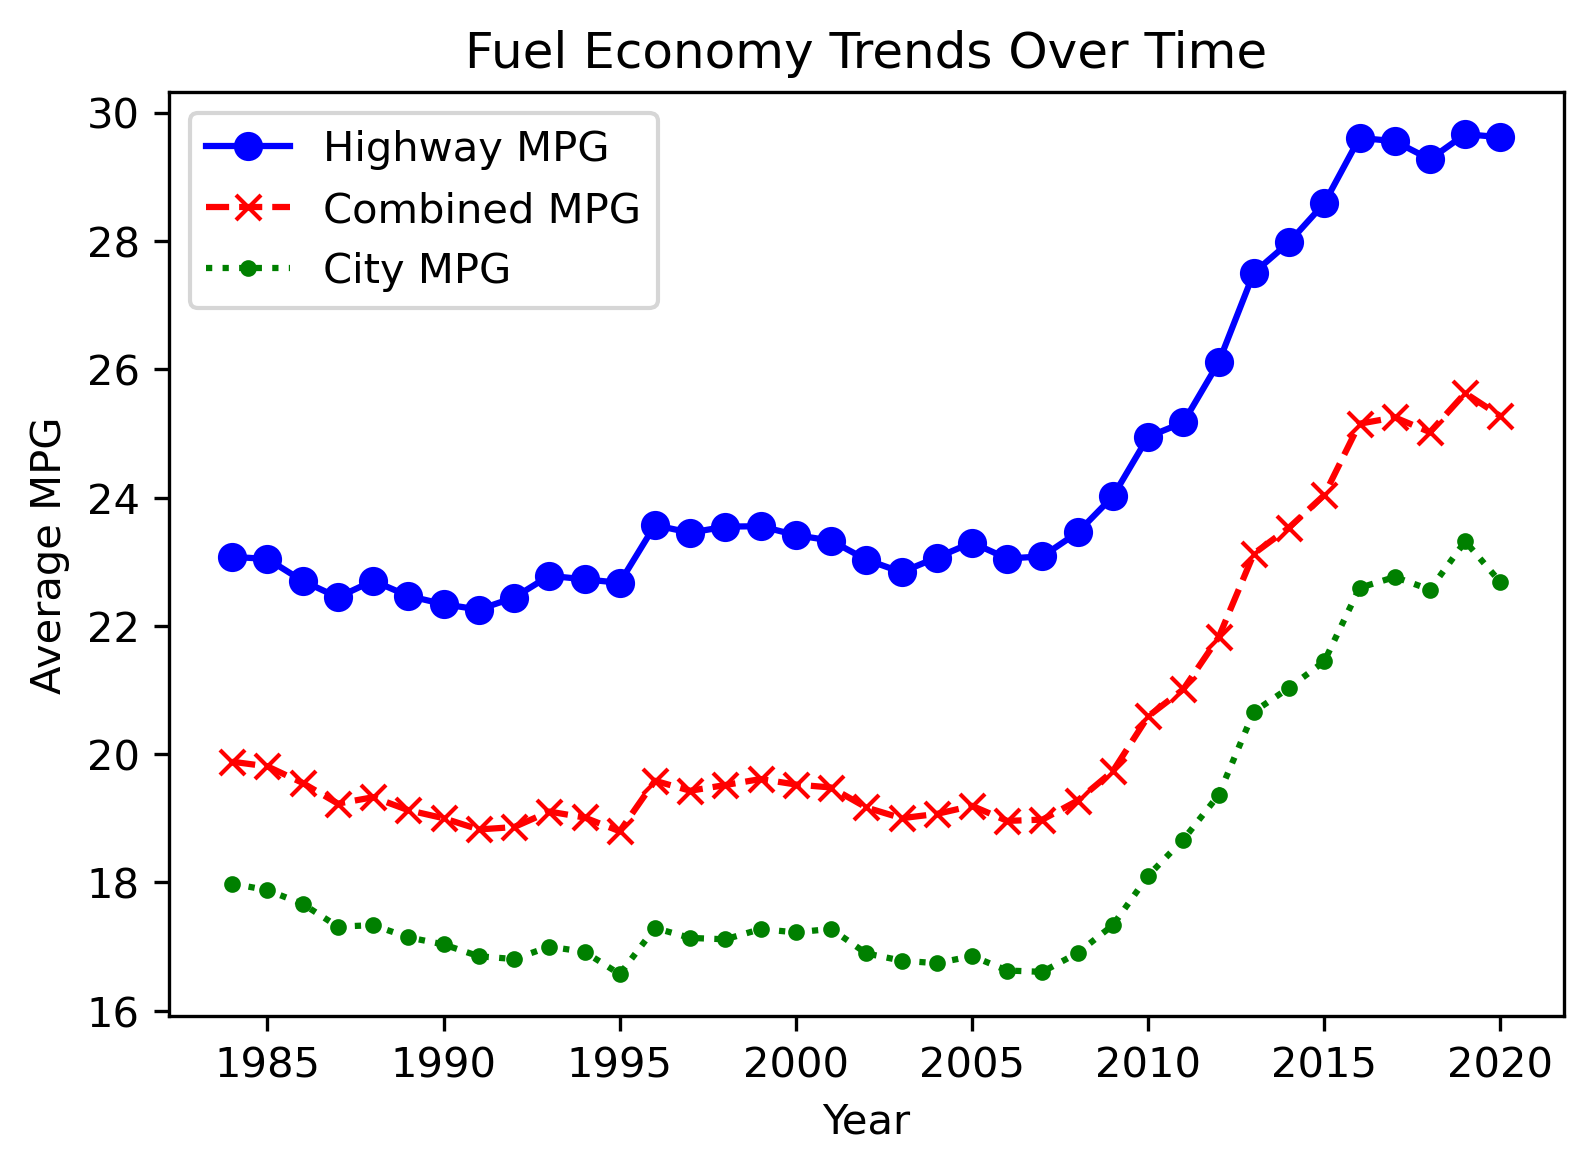

In [ ]:
fig,ax=plt.subplots(figsize=(6,4),dpi=300)

yearly_hw_mpg=data.groupby('year')['highway08'].mean()
#print(yearly_hw_mpg)

#first line plot using ax:
ax.plot(yearly_hw_mpg.index,yearly_hw_mpg.values,marker='o',linestyle='-',color='blue',label='Highway MPG')
#second line plot using plt:
plt.plot(data.groupby('year')['comb08'].mean(),marker='x',linestyle='--',color='red',label='Combined MPG')
#third line plot using Pandas plot
data.groupby('year')['city08'].mean().plot(ax=ax,marker='.',linestyle=':',color='green',label='City MPG')

ax.set_title("Fuel Economy Trends Over Time")
ax.set_xlabel('Year')
ax.set_ylabel('Average MPG')
ax.legend()

### Bar Charts

Text(0.5, 1.0, 'Average Combined MPG by Make')

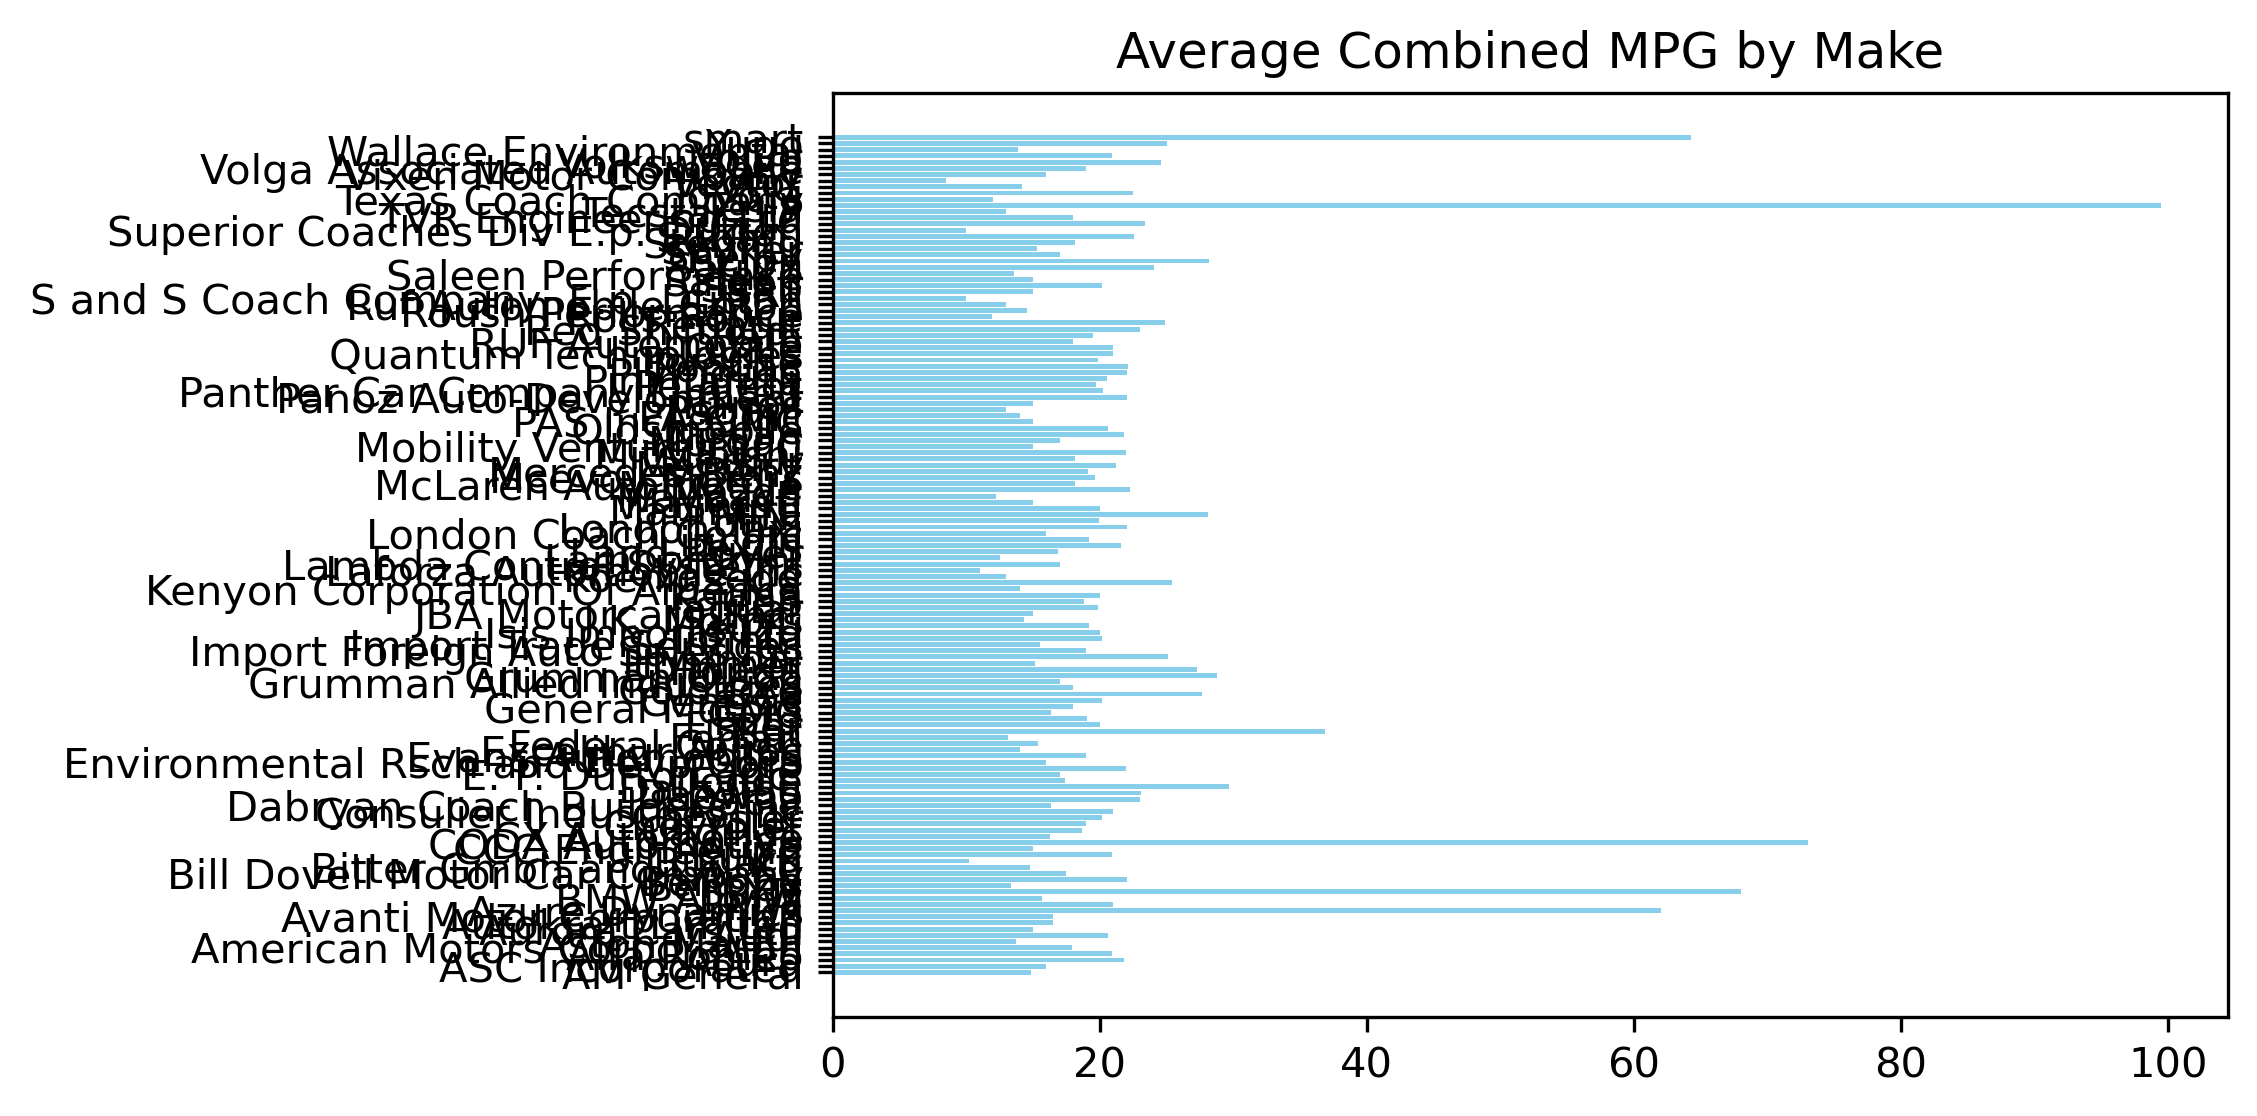

In [48]:
fig,ax=plt.subplots(figsize=(6,4),dpi=300)

make_mpg=data.groupby('make')['comb08'].mean()
ax.barh(make_mpg.index, make_mpg.values, color='skyblue')
ax.set_title('Average Combined MPG by Make')
#the plot has too many categories and is not readable
#uppler limit for bars categories: 20

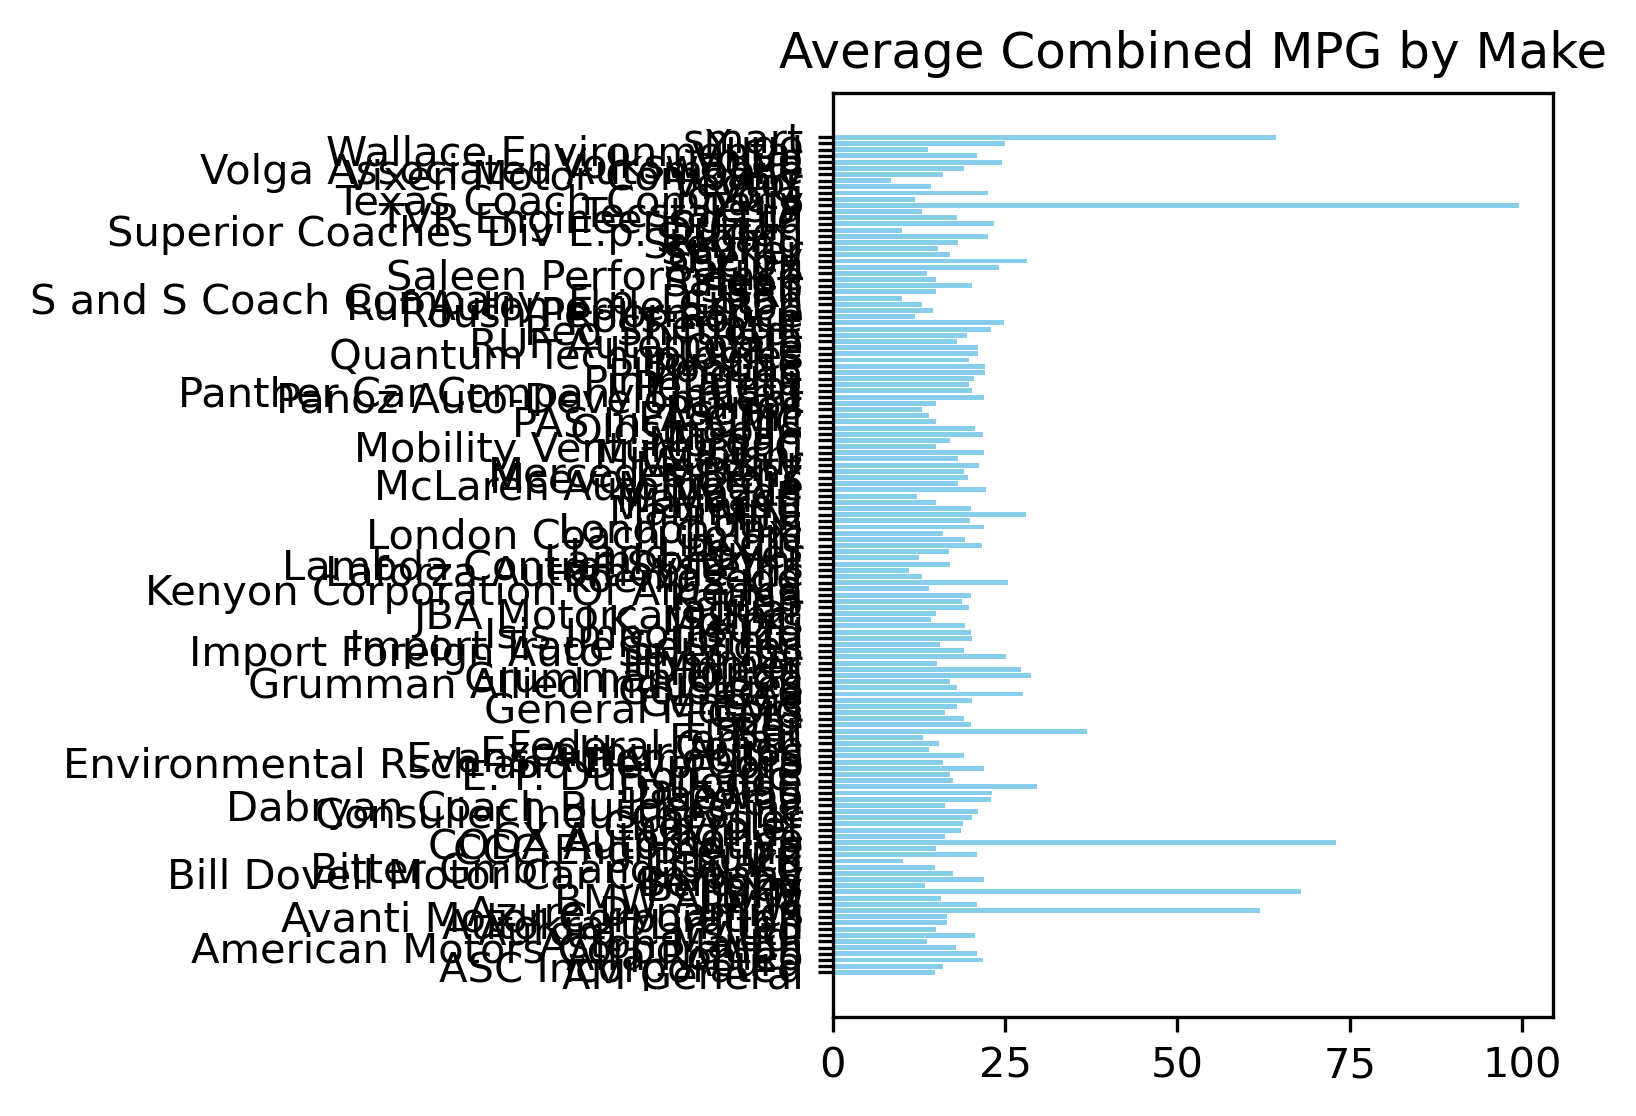

In [49]:
fig,ax=plt.subplots(figsize=(6,4),dpi=300)

make_mpg=data.groupby('make')['comb08'].mean()
ax.barh(make_mpg.index, make_mpg.values, color='skyblue')
ax.set_title('Average Combined MPG by Make')
#set the left padding using subplot_adjust:
fig.subplots_adjust(left=0.5)

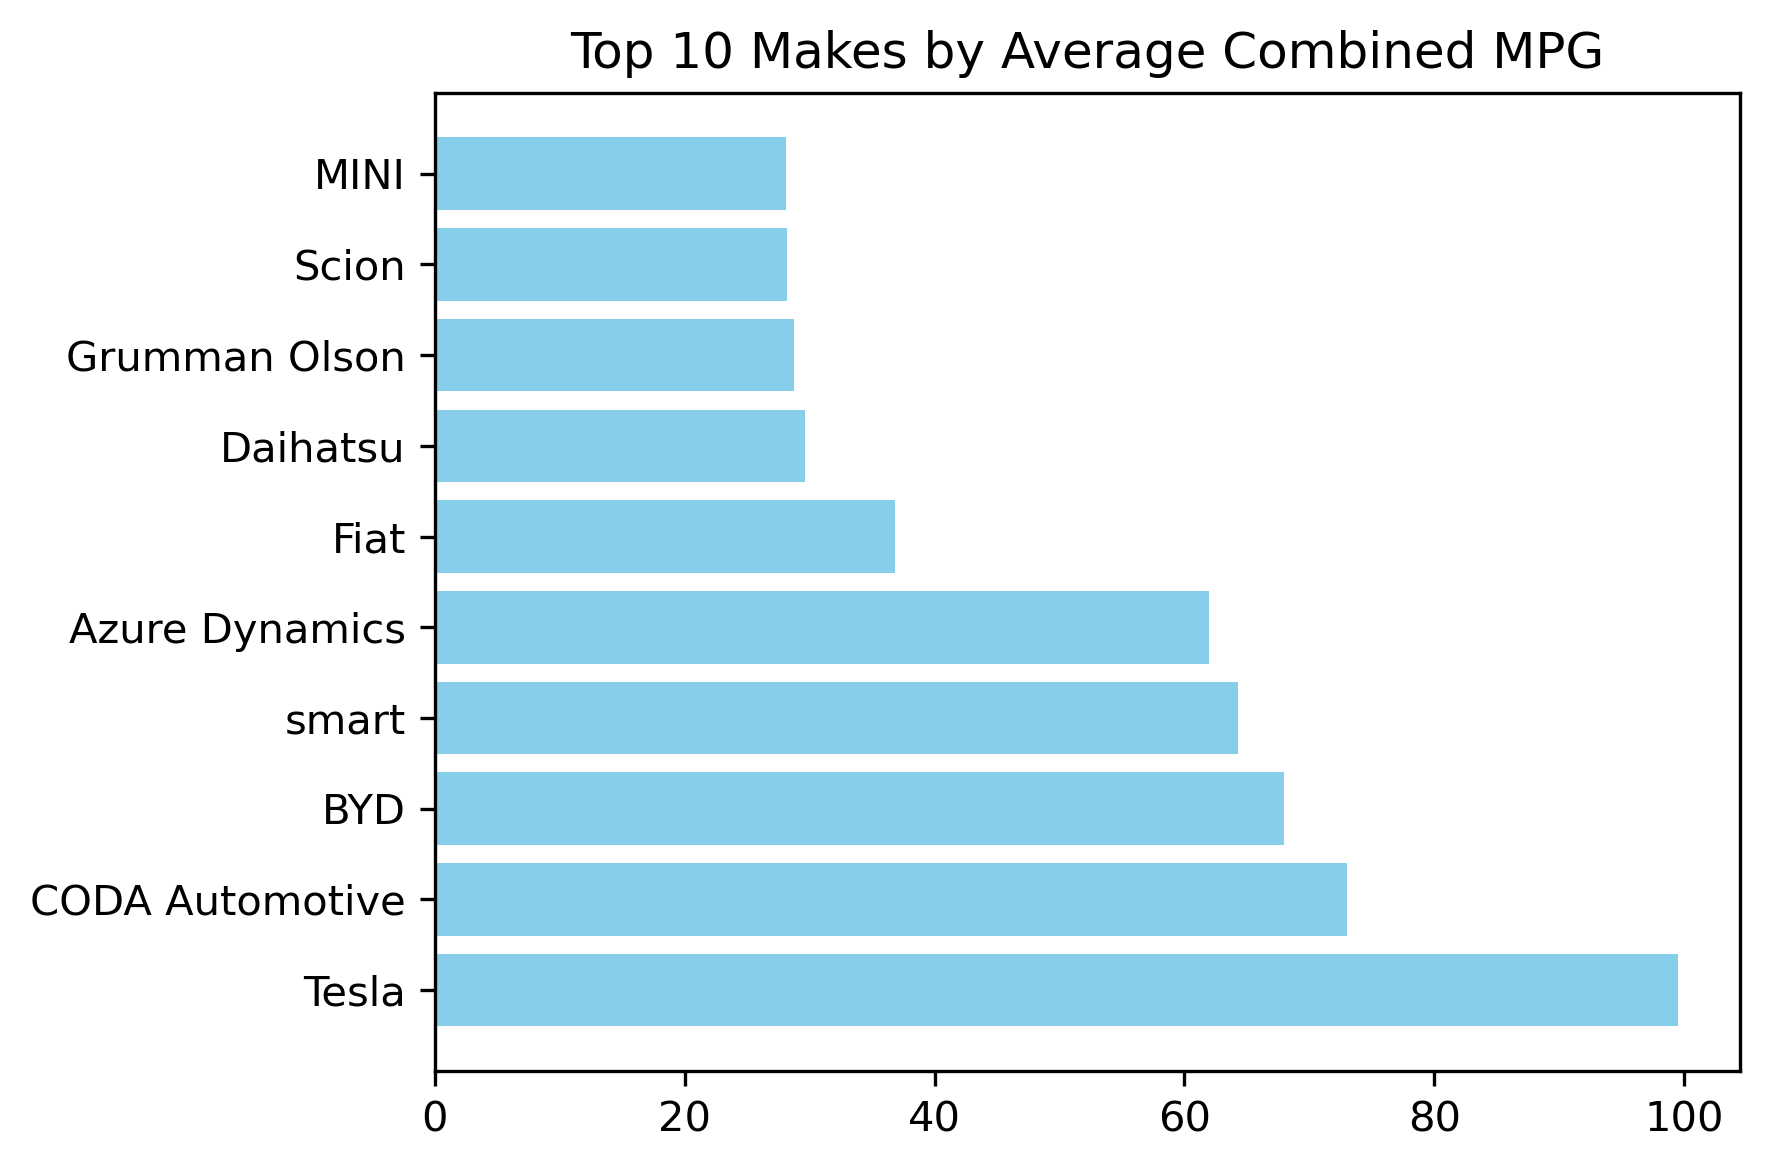

In [50]:
fig,ax=plt.subplots(figsize=(6,4),dpi=300)

n=10
#use pandas .nlargest method to get the top 10 manufacturers. 
make_mpg=data.groupby('make')['comb08'].mean().nlargest(n)
ax.barh(make_mpg.index, make_mpg.values, color='skyblue')
ax.set_title(f'Top {n} Makes by Average Combined MPG')
#use tight_layout to adjust clipping: 
plt.tight_layout()
#in addition to tight_layout, there is constrained_layout, and subplots_adjust

<AxesSubplot:title={'center':'Pandas Bar Plot'}, ylabel='make'>

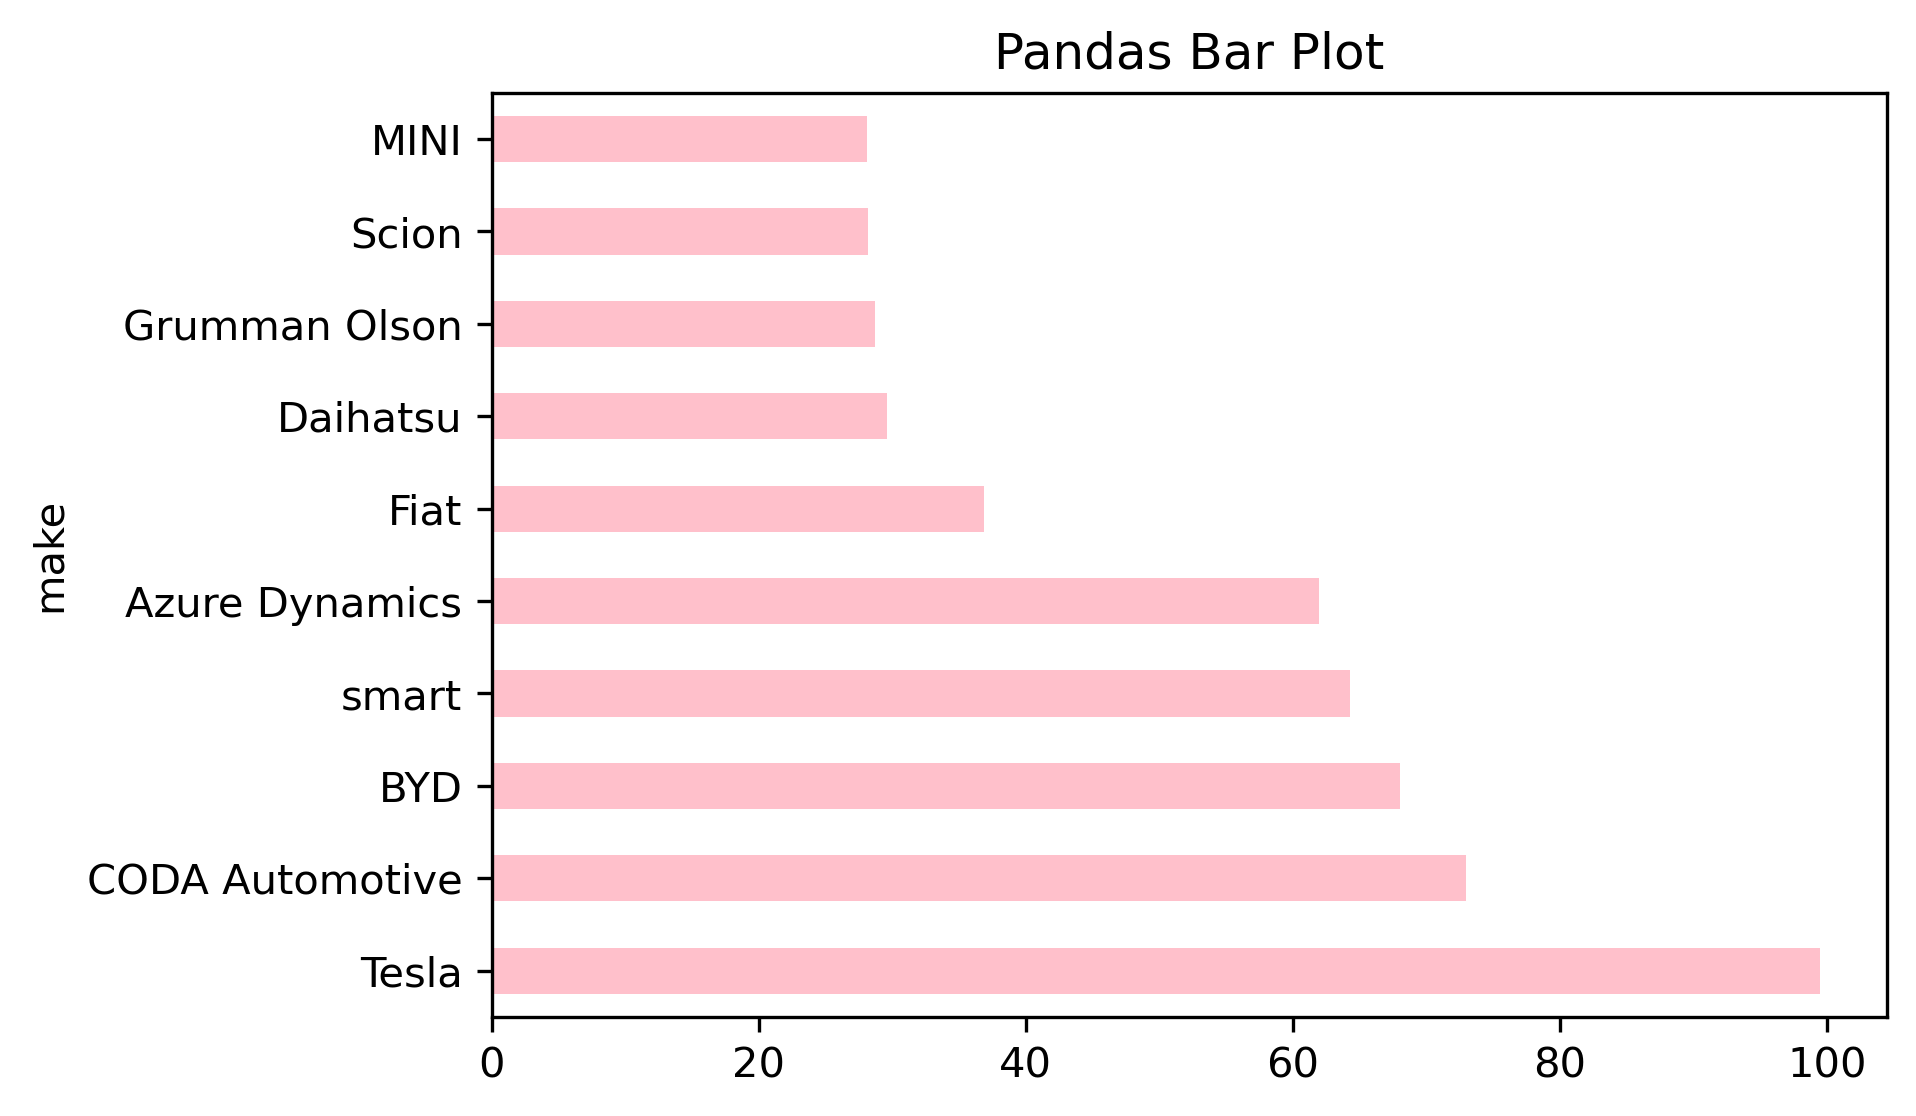

In [51]:
#create the above plot directly from pandas:
fig,ax=plt.subplots(figsize=(6,4),dpi=300)
n=10

data.groupby('make')['comb08'].mean().nlargest(n).plot.barh(ax=ax,color='pink',title="Pandas Bar Plot")

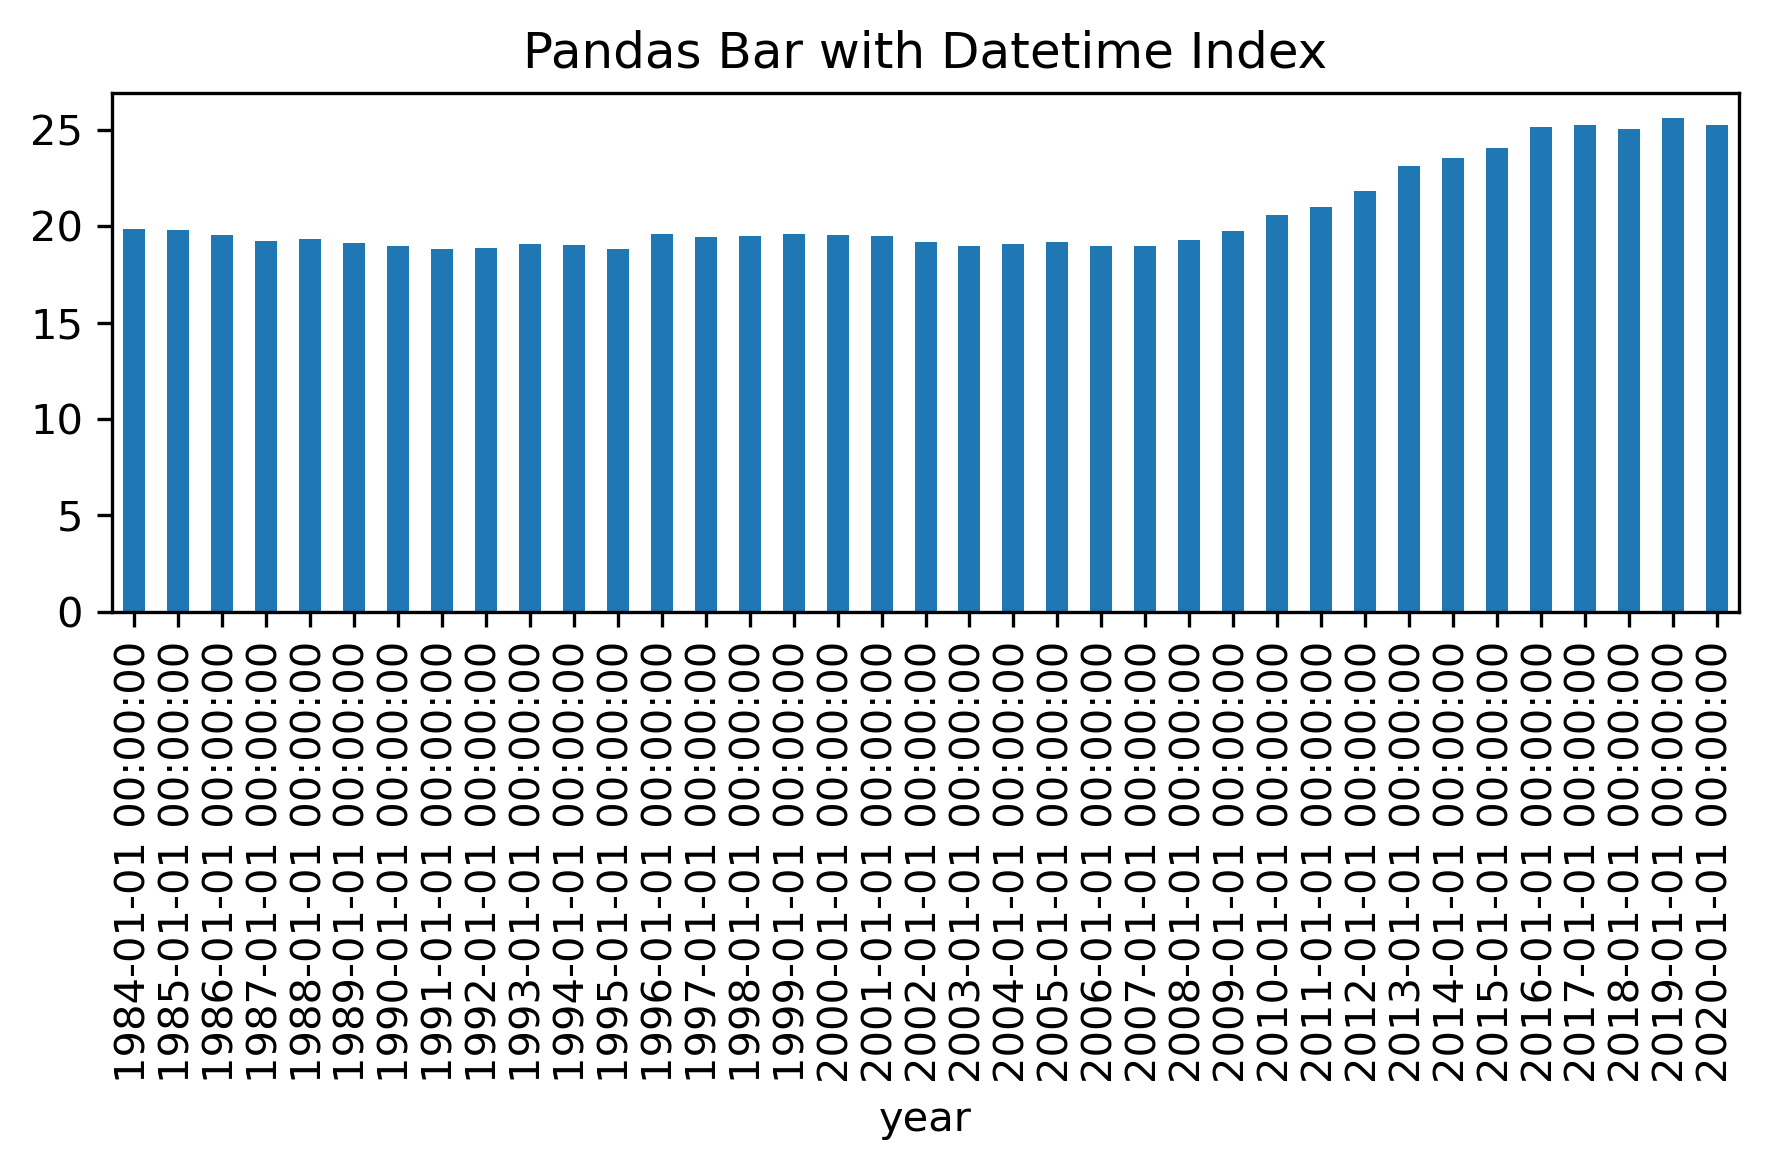

In [ ]:
#be careful with dates and bar plots. Pandas will automatically convert the index into a label from the x-axis
# Pandas Plot
fig,ax=plt.subplots(figsize=(6,4),dpi=300)

year_mpg=(data
.assign(year=pd.to_datetime(data['year'],format='%Y'))
.groupby('year')['comb08']
.mean())

year_mpg.plot.bar(ax=ax,title='Pandas Bar with Datetime Index')
plt.tight_layout()


Text(0.5, 1.0, 'Bar Plot with Datetime Index(created with ax.bar)')

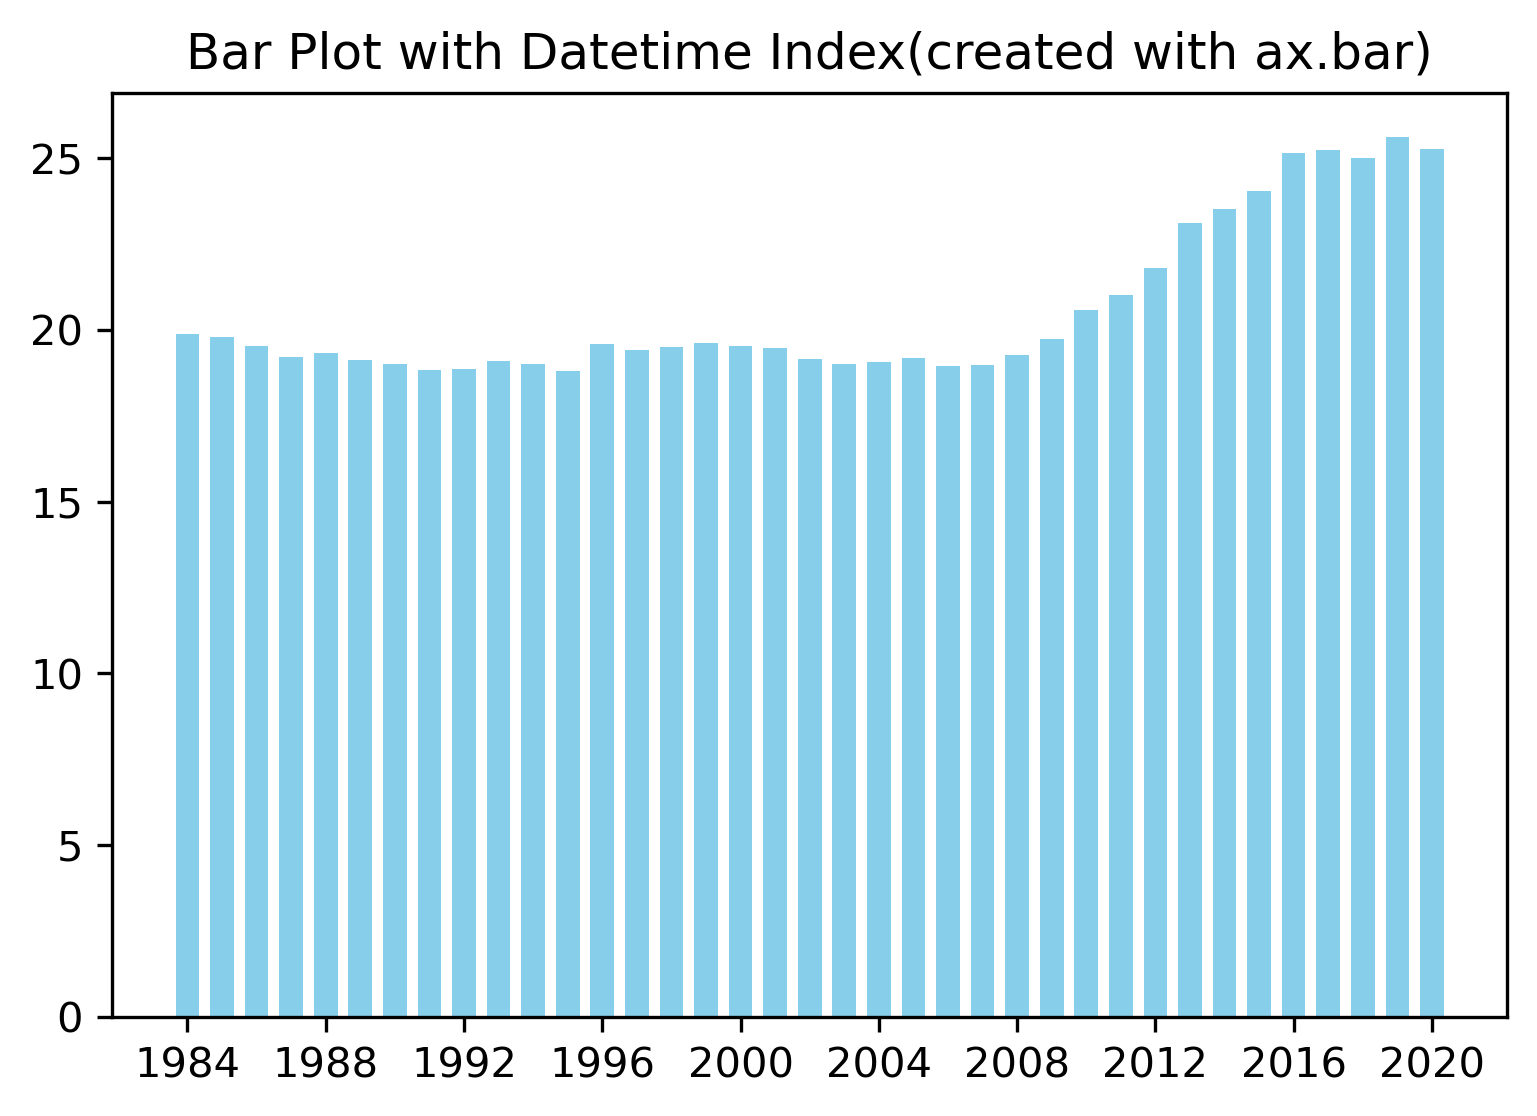

In [62]:
#AX plot
fig,ax=plt.subplots(figsize=(6,4),dpi=300)

year_mpg=(data
.assign(year=pd.to_datetime(data['year'],format='%Y'))
.groupby('year')['comb08']
.mean()) #add parentheses around the data so all lines are counted continuous

ax.bar(year_mpg.index,year_mpg,color='skyblue',width=250)
ax.set_title('Bar Plot with Datetime Index(created with ax.bar)')

In [60]:
year_mpg.index

DatetimeIndex(['1984-01-01', '1985-01-01', '1986-01-01', '1987-01-01',
               '1988-01-01', '1989-01-01', '1990-01-01', '1991-01-01',
               '1992-01-01', '1993-01-01', '1994-01-01', '1995-01-01',
               '1996-01-01', '1997-01-01', '1998-01-01', '1999-01-01',
               '2000-01-01', '2001-01-01', '2002-01-01', '2003-01-01',
               '2004-01-01', '2005-01-01', '2006-01-01', '2007-01-01',
               '2008-01-01', '2009-01-01', '2010-01-01', '2011-01-01',
               '2012-01-01', '2013-01-01', '2014-01-01', '2015-01-01',
               '2016-01-01', '2017-01-01', '2018-01-01', '2019-01-01',
               '2020-01-01'],
              dtype='datetime64[ns]', name='year', freq=None)

### Histogram

<AxesSubplot:title={'center':'Pandas Histogram'}, ylabel='Frequency'>

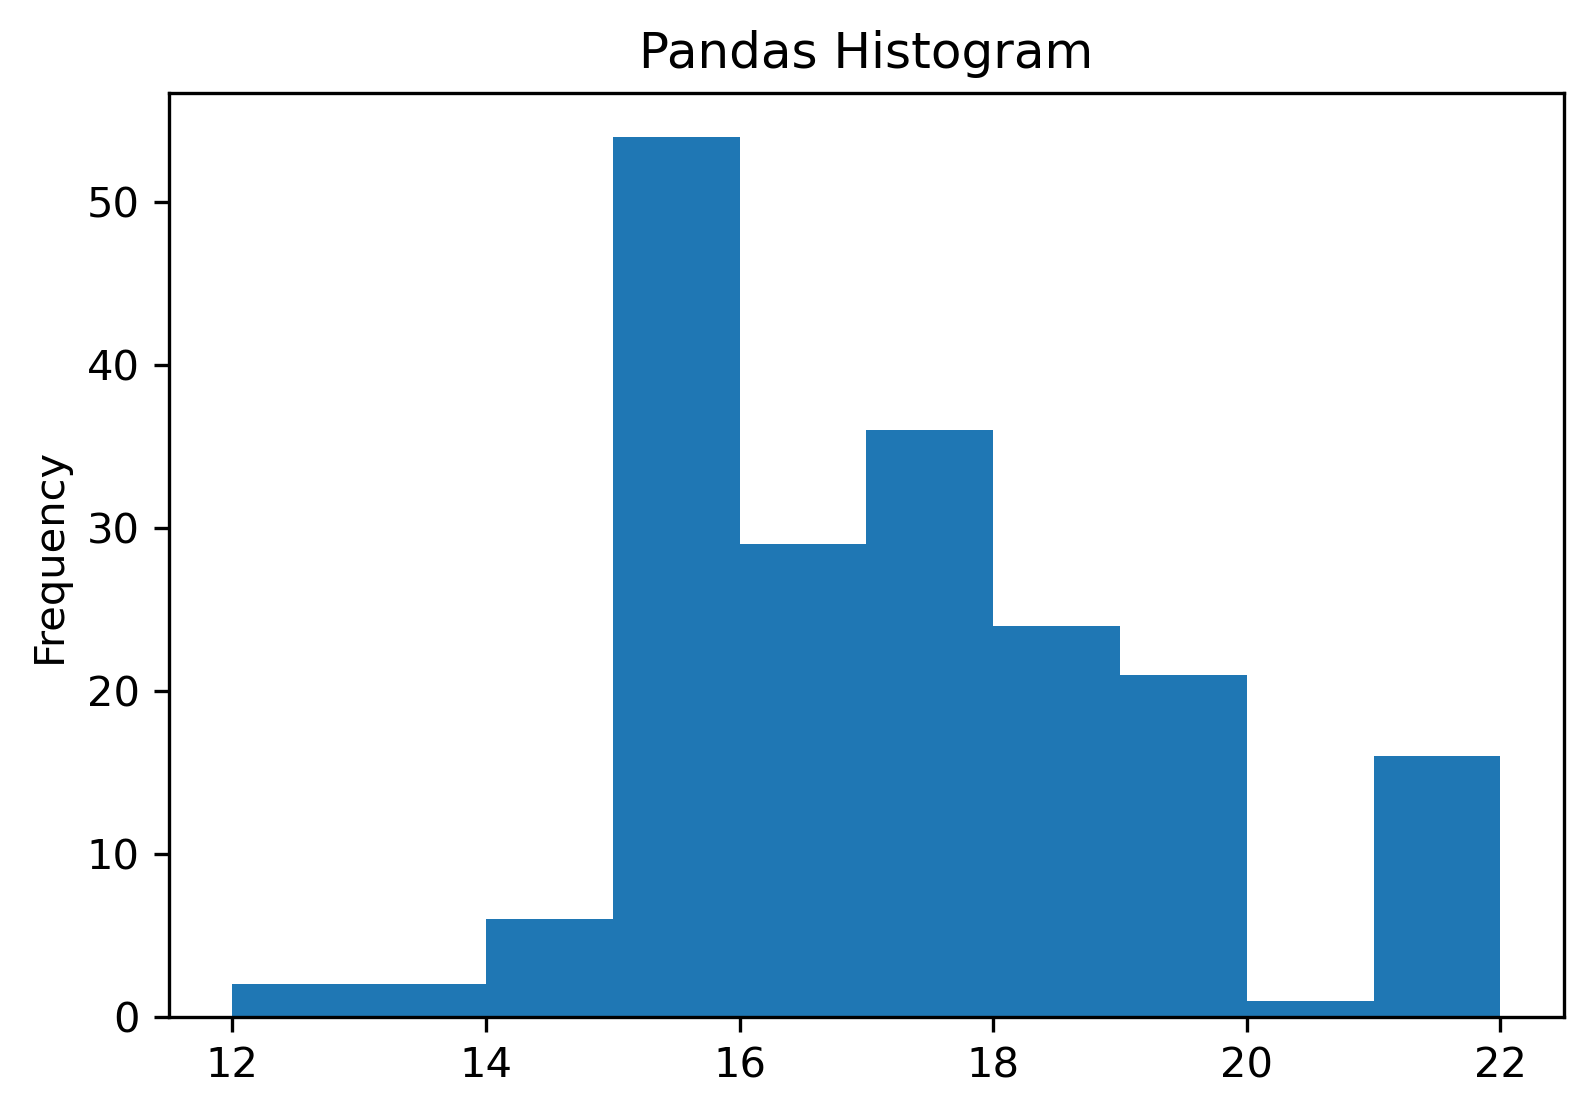

In [64]:
# Using Pandas
fig,ax=plt.subplots(figsize=(6,4),dpi=300)
data.query('make=="Ford" and model=="Mustang"').city08.plot.hist(ax=ax,title="Pandas Histogram")
           
        

Text(0.5, 1.0, 'Histograms with ax.hist')

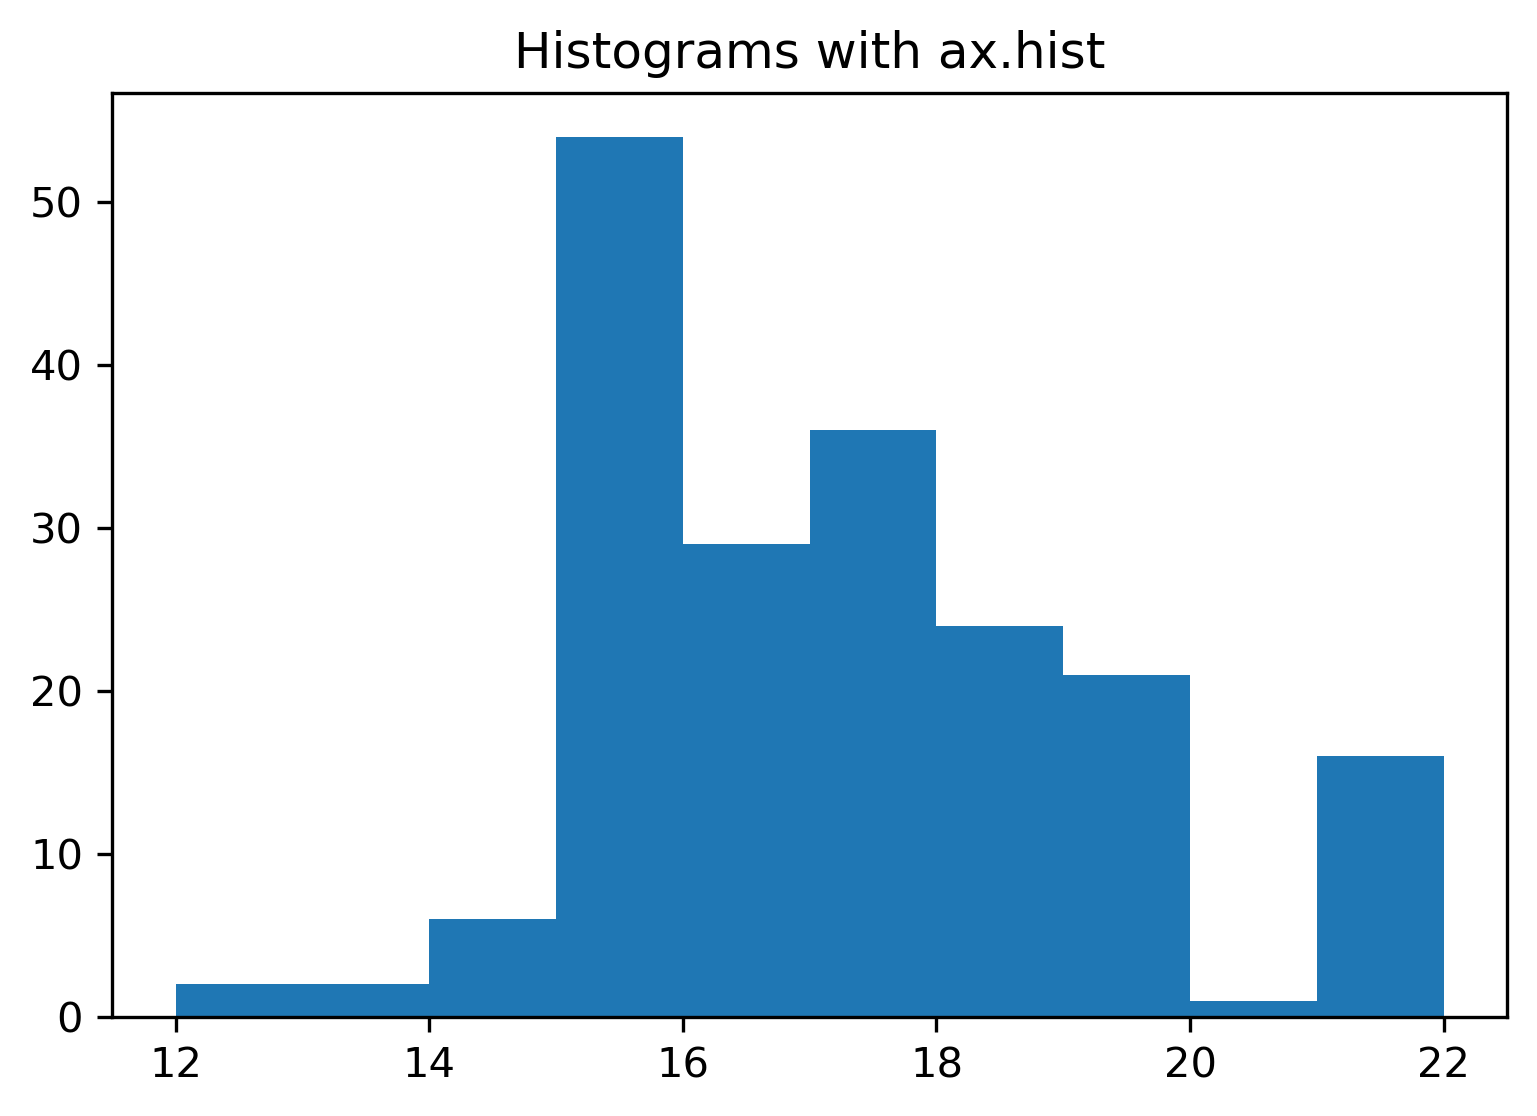

In [69]:
# Using Axes object
fig,ax=plt.subplots(figsize=(6,4),dpi=300)

ax.hist(data.query('make=="Ford" and model=="Mustang"')['city08'])
        
ax.set_title("Histograms with ax.hist")